In [1]:
# !pip install openpyxl

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

In [3]:
fp_avail="gs://agntworks-data-dev/sandbox/experiments/Available Flights Last 18 mos.xlsx"
fp_comp="gs://agntworks-data-dev/sandbox/experiments/Completed-Flights-2016.xlsx"
fp_quotes="gs://agntworks-data-dev/sandbox/experiments/XODM-quotes-trips-2016.xlsx"

avail = pd.read_excel(fp_avail)
completed = pd.read_excel(fp_comp)
quotes_2016 = pd.read_excel(fp_quotes, sheet_name='2016')

In [4]:
# trip dataset build from initial analysis

def _to_timedelta(s: pd.Series) -> pd.Series:
    # Handles strings like '02:44:00' and missing values
    return pd.to_timedelta(s.astype('string'), errors='coerce')


# Trip-level aggregation from completed legs
completed_leg = completed.copy()
completed_leg['Dep_DT_GMT'] = pd.to_datetime(completed_leg['Dep_Date_Actual_GMT']) + _to_timedelta(completed_leg['Dep_Time_Actual_GMT'])
completed_leg['Arr_DT_GMT'] = pd.to_datetime(completed_leg['Arr_Date_Actual_GMT']) + _to_timedelta(completed_leg['Arr_Time_Actual_GMT'])

block_min = (completed_leg['Arr_DT_GMT'] - completed_leg['Dep_DT_GMT']).dt.total_seconds() / 60
completed_leg['Block_Min'] = block_min.where(block_min > 0)

for c in ['Statute_Miles', 'PAX_Count', 'DHflag', 'Leg_Number', 'Leg_Count']:
    completed_leg[c] = pd.to_numeric(completed_leg[c], errors='coerce')

trip_agg = (
    completed_leg
    .groupby('Trip_Number', dropna=False)
    .agg(
        n_legs=('Trip_Legs_ID', 'nunique'),
        leg_count_max=('Leg_Count', 'max'),
        miles_total=('Statute_Miles', 'sum'),
        block_min_total=('Block_Min', 'sum'),
        pax_max=('PAX_Count', 'max'),
        dh_legs=('DHflag', 'sum'),
        miles_dh=('Statute_Miles', lambda x: x[completed_leg.loc[x.index, 'DHflag'].fillna(0).astype(int) == 1].sum()),
        dep_dt_min=('Dep_DT_GMT', 'min'),
        arr_dt_max=('Arr_DT_GMT', 'max'),
        dep_icao_first=('Dep_ICAO', 'first'),
        arr_icao_last=('Arr_ICAO', 'last'),
        trip_type_code=('Trip_type_code', 'first'),
        trip_purpose=('Trip_Purpose', 'first'),
        aircraft_type_id=('Aircraft_Type_ID', 'first'),
        aircraft_id=('Aircraft_ID', 'first'),
        quote_total_cost=('Quote_Total_Cost', 'first'),
        ac_cost_total=('AC_Cost_Total', 'first'),
    )
    .reset_index()
)

trip_agg['dh_share_miles'] = (trip_agg['miles_dh'] / trip_agg['miles_total']).replace([np.inf, -np.inf], np.nan)
trip_agg['block_hr_total'] = trip_agg['block_min_total'] / 60
trip_agg['speed_mph'] = (trip_agg['miles_total'] / trip_agg['block_hr_total']).replace([np.inf, -np.inf], np.nan)
trip_agg['cost_per_mile_actual'] = (trip_agg['quote_total_cost'] / trip_agg['miles_total']).replace([np.inf, -np.inf], np.nan)
trip_agg['cost_per_block_hr_actual'] = (trip_agg['quote_total_cost'] / trip_agg['block_hr_total']).replace([np.inf, -np.inf], np.nan)
trip_agg['margin_vs_ac_cost'] = trip_agg['quote_total_cost'] - trip_agg['ac_cost_total']
trip_agg['margin_pct_vs_ac_cost'] = (trip_agg['margin_vs_ac_cost'] / trip_agg['quote_total_cost']).replace([np.inf, -np.inf], np.nan)

trip_agg['dep_month'] = trip_agg['dep_dt_min'].dt.to_period('M').astype('string')
trip_agg['dep_dow'] = trip_agg['dep_dt_min'].dt.day_name()

# Join latest quote row per Trip_Number
quotes_trip = quotes_2016.copy()
quotes_trip['Trip_Number'] = pd.to_numeric(quotes_trip['Trip_Number'], errors='coerce')
quotes_trip = quotes_trip.sort_values('Last_Update_Date').drop_duplicates(subset=['Trip_Number'], keep='last')

trip = trip_agg.merge(
    quotes_trip[[
        'Trip_Number', 'Trip_Status', 'Date_Quoted', 'Scheduled_Date', 'Trip_Departure_Date', 'Trip_Arrival_Date',
        'Percent_Discount', 'Quote_Status', 'Quoted_Route', 'Live_Leg_City_Pairs', 'qTrip_type_code', 'qRate_Type_Code',
        'Aircraft_Rate', 'DHRate', 'Company_Code', 'Quoted_For_Company', 'Last_Update_Date'
    ]],
    on='Trip_Number',
    how='left'
)

# Basic cleaning consistent with earlier notebook
trip_cln = trip.copy()
trip_cln.loc[trip_cln['miles_total'] <= 0, ['cost_per_mile_actual']] = np.nan
trip_cln.loc[trip_cln['block_hr_total'] <= 0, ['cost_per_block_hr_actual', 'speed_mph']] = np.nan
trip_cln = trip_cln[trip_cln['quote_total_cost'] >= 0].copy()

trip_realized = trip_cln[trip_cln['Quote_Status'].fillna('NA').isin(['Invoiced - Ready to Export', 'Paid - Exported to Accounting'])].copy()

In [5]:
# Booking lead time features
trip_realized['Date_Quoted'] = pd.to_datetime(trip_realized['Date_Quoted'], errors='coerce')
trip_realized['Trip_Departure_Date'] = pd.to_datetime(trip_realized['Trip_Departure_Date'], errors='coerce')
trip_realized['lead_time_days'] = (trip_realized['Trip_Departure_Date'] - trip_realized['Date_Quoted']).dt.total_seconds() / (3600 * 24)
trip_realized.loc[trip_realized['lead_time_days'] < 0, 'lead_time_days'] = np.nan  # guard against dirty timestamps

trip_realized['quoted_dow'] = trip_realized['Date_Quoted'].dt.day_name()
trip_realized['quoted_month'] = trip_realized['Date_Quoted'].dt.to_period('M').astype('string')

print('trip_realized shape:', trip_realized.shape)
print('Customers (Quoted_For_Company) non-null:', trip_realized['Quoted_For_Company'].notna().sum())
print('Lead time available (non-null):', trip_realized['lead_time_days'].notna().sum())
trip_realized[['Trip_Number','Quoted_For_Company','Date_Quoted','Trip_Departure_Date','lead_time_days','quoted_dow','dep_dow','quote_total_cost']].head(5)

trip_realized shape: (3835, 46)
Customers (Quoted_For_Company) non-null: 3835
Lead time available (non-null): 3831


,Trip_Number,Quoted_For_Company,Date_Quoted,Trip_Departure_Date,lead_time_days,quoted_dow,dep_dow,quote_total_cost
3,162484,MacGregor & Mary Read Revocable Trust - PRF6,2016-01-14,2016-04-07,84.0,Thursday,Friday,158855.00
54,169174,Arthur Hershaft - PRF6,2016-01-04,2016-01-25,21.0,Monday,Monday,26800.00
68,169809,Stone Ridge Asset Management - PRF6,2016-03-28,2016-03-21,NaN,Monday,Monday,88591.31
84,170330,Patricia Hearst Shaw - PRF2,2016-01-01,2016-01-01,0.0,Friday,Friday,34561.76
409,174203,Mark Burnett Productions - PRF5,2016-01-01,2016-01-05,4.0,Friday,Tuesday,26225.08


# new

In [6]:
# Analyze booking lead time + weekday patterns at overall and customer-segment level

# Basic sanity / trimming for visuals
lt = trip_realized['lead_time_days'].copy()
lt_valid = lt[(lt.notna()) & (lt >= 0) & (lt <= 365)]  # cap at 1y for interpretability

print('Lead time summary (days), capped to [0,365] for plots:')
print(lt_valid.describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99]).round(2))

Lead time summary (days), capped to [0,365] for plots:
count    3831.00
mean       14.38
std        18.14
min         0.00
1%          0.00
5%          1.00
10%         1.00
25%         3.00
50%         8.00
75%        19.00
90%        35.00
95%        51.00
99%        86.70
max       158.00
Name: lead_time_days, dtype: float64


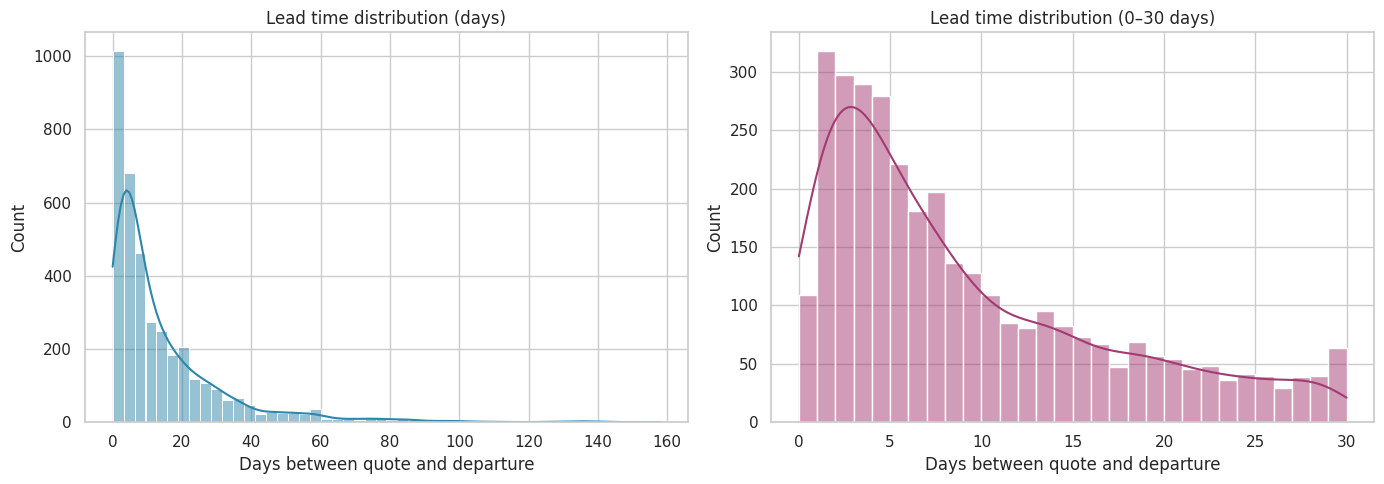

In [7]:
# --- 1) Overall lead-time distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(lt_valid, bins=50, kde=True, ax=axes[0], color="#2E86AB")
axes[0].set_title('Lead time distribution (days)')
axes[0].set_xlabel('Days between quote and departure')

# zoomed in (0-30 days) to see last-minute behavior
lt_30 = lt_valid[lt_valid <= 30]
sns.histplot(lt_30, bins=30, kde=True, ax=axes[1], color="#A23B72")
axes[1].set_title('Lead time distribution (0–30 days)')
axes[1].set_xlabel('Days between quote and departure')

plt.tight_layout()
plt.show()

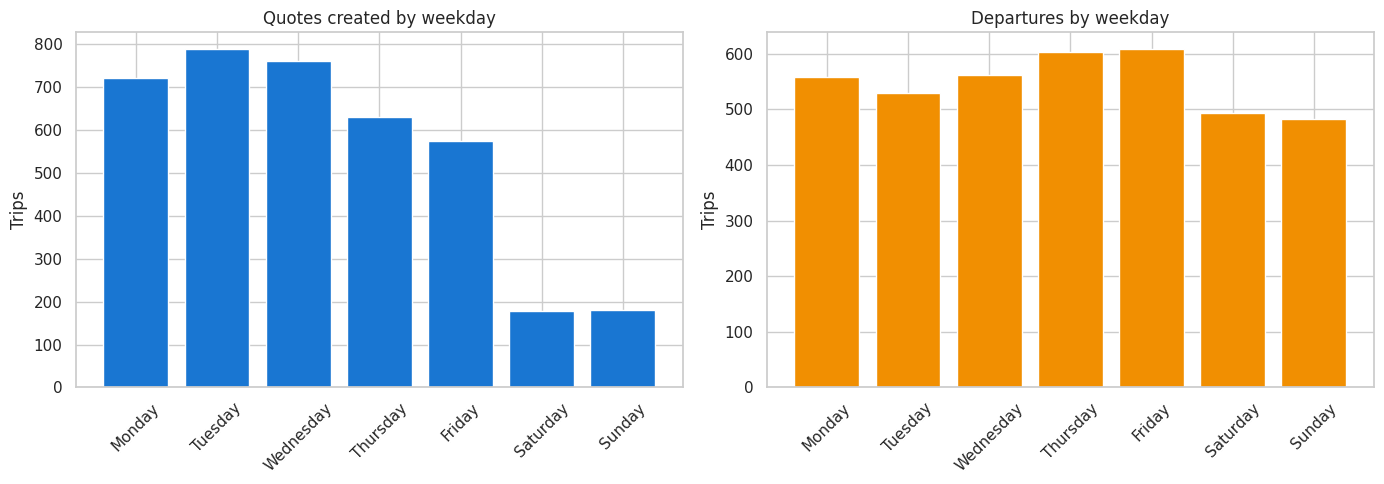

In [8]:
# --- 2) Weekday patterns: when do customers quote vs when do they depart ---
week_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

quote_dow_counts = trip_realized['quoted_dow'].value_counts().reindex(week_order)
dep_dow_counts = trip_realized['dep_dow'].value_counts().reindex(week_order)

axes[0].bar(quote_dow_counts.index, quote_dow_counts.values, color="#1976D2")
axes[0].set_title('Quotes created by weekday')
axes[0].set_ylabel('Trips')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(dep_dow_counts.index, dep_dow_counts.values, color="#F18F01")
axes[1].set_title('Departures by weekday')
axes[1].set_ylabel('Trips')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

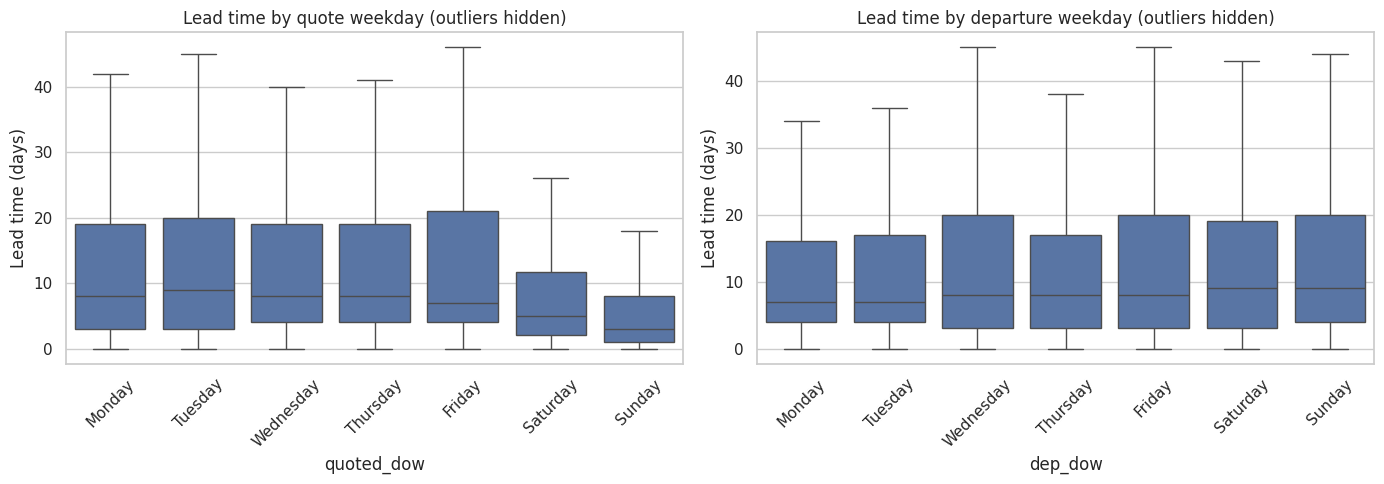

In [9]:
# --- 3) Lead time by quote weekday / departure weekday ---
plot_lt = trip_realized[['lead_time_days','quoted_dow','dep_dow']].copy()
plot_lt = plot_lt[(plot_lt['lead_time_days'].notna()) & (plot_lt['lead_time_days']>=0) & (plot_lt['lead_time_days']<=365)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=plot_lt, x='quoted_dow', y='lead_time_days', order=week_order, showfliers=False, ax=axes[0])
axes[0].set_title('Lead time by quote weekday (outliers hidden)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Lead time (days)')

sns.boxplot(data=plot_lt, x='dep_dow', y='lead_time_days', order=week_order, showfliers=False, ax=axes[1])
axes[1].set_title('Lead time by departure weekday (outliers hidden)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Lead time (days)')

plt.tight_layout()
plt.show()

In [10]:
# --- 4) Customer-level "booking style" segmentation ---
# Define: last-minute share (<=7 days), typical lead time (median), and sample size
cust_lt = (
    trip_realized
    .assign(lead_time_days_clip=lambda d: d['lead_time_days'].where((d['lead_time_days']>=0) & (d['lead_time_days']<=365)))
    .groupby('Quoted_For_Company')
    .agg(
        n_trips=('Trip_Number','size'),
        lead_median=('lead_time_days_clip','median'),
        lead_p25=('lead_time_days_clip', lambda s: s.quantile(0.25)),
        lead_p75=('lead_time_days_clip', lambda s: s.quantile(0.75)),
        last_minute_share_7d=('lead_time_days_clip', lambda s: (s<=7).mean()),
        very_last_minute_share_2d=('lead_time_days_clip', lambda s: (s<=2).mean()),
        total_revenue=('quote_total_cost','sum'),
        avg_margin_pct=('margin_pct_vs_ac_cost','mean')
    )
    .reset_index()
)

# Keep customers with enough history for stable patterns
cust_lt_sig = cust_lt[cust_lt['n_trips'] >= 10].copy()

print('Customers with >=10 realized trips:', len(cust_lt_sig))

Customers with >=10 realized trips: 58


In [11]:
# Segment rules (simple + interpretable)
# - "Last-minute" if >=50% of trips quoted within 7 days
# - "Planners" if median lead time >=21 days
# - else "Mixed"
conds = [
    cust_lt_sig['last_minute_share_7d'] >= 0.50,
    cust_lt_sig['lead_median'] >= 21,
]
choices = ['Last-minute bookers', 'Planners (>=21d median)']
cust_lt_sig['booking_style'] = np.select(conds, choices, default='Mixed')

style_summary = (
    cust_lt_sig.groupby('booking_style')
    .agg(
        customers=('Quoted_For_Company','nunique'),
        trips=('n_trips','sum'),
        med_lead=('lead_median','median'),
        med_last_minute_7d=('last_minute_share_7d','median'),
        total_revenue=('total_revenue','sum'),
        avg_margin_pct=('avg_margin_pct','mean')
    )
    .sort_values('trips', ascending=False)
)

print('\nBooking style summary (customers with >=10 trips):')
display(style_summary.round(3))


Booking style summary (customers with >=10 trips):


,customers,trips,med_lead,med_last_minute_7d,total_revenue,avg_margin_pct
booking_style,,,,,,
Mixed,25,634,10.00,0.364,18018217.27,0.106
Last-minute bookers,29,585,4.00,0.722,17396490.14,0.146
Planners (>=21d median),4,54,30.25,0.134,2090564.58,0.158


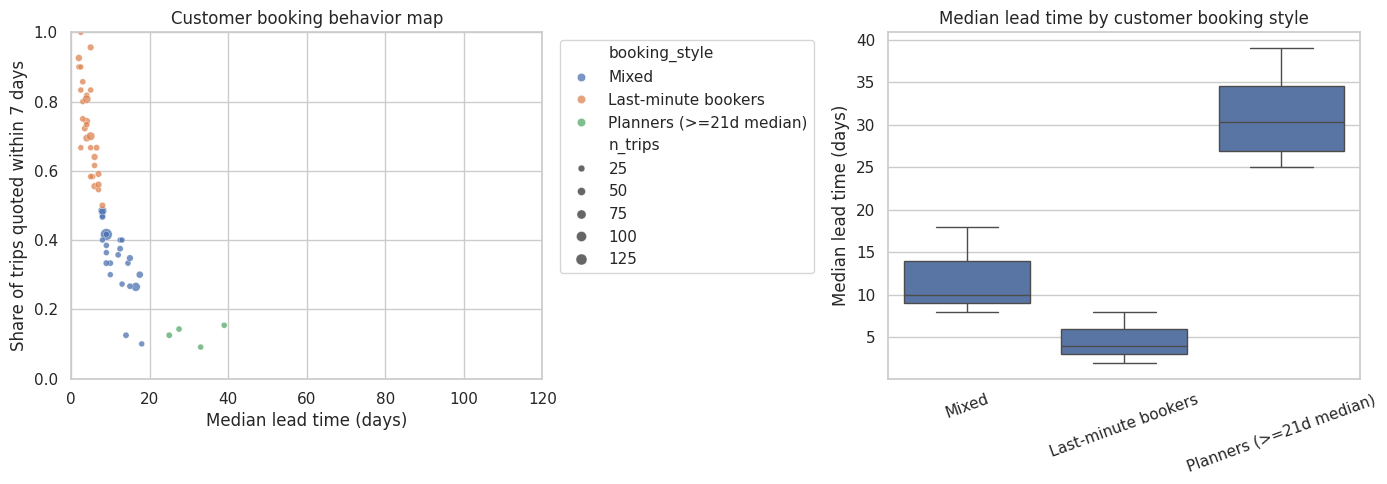


Top revenue customers within each booking style (>=10 trips):


,Quoted_For_Company,n_trips,lead_median,last_minute_share_7d,very_last_minute_share_2d,total_revenue,avg_margin_pct
83,"Apple, Inc",27,6.0,0.556,0.148,2055750.0,0.242
738,Magellan Jets,60,5.0,0.700,0.217,1355813.0,-0.062
1029,SAP,25,6.0,0.640,0.240,967727.0,0.221
616,"JetSmarter, Inc.",35,4.0,0.743,0.286,932592.0,-0.035
747,Margaritaville Holdings LLC - PRF4,23,5.0,0.957,0.130,878399.0,0.282
605,Jet Linx Aviation,57,4.0,0.807,0.193,846026.0,0.054
617,Jets.com,36,4.0,0.694,0.278,767770.0,-0.002
1075,Silver Lake Technology Mgmt - PRF4,25,7.0,0.560,0.200,761517.0,0.145
1008,Robert Duggan - PRF5,15,4.0,0.733,0.333,710744.0,0.081
501,Hari Ravichandran - PRF5,18,3.5,0.722,0.444,703049.0,0.205


In [12]:
# Visual: customer booking style vs revenue and margin
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=cust_lt_sig,
    x='lead_median',
    y='last_minute_share_7d',
    size='n_trips',
    hue='booking_style',
    alpha=0.75,
    ax=axes[0]
)
axes[0].set_title('Customer booking behavior map')
axes[0].set_xlabel('Median lead time (days)')
axes[0].set_ylabel('Share of trips quoted within 7 days')
axes[0].set_xlim(0, 120)
axes[0].set_ylim(0, 1)
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left')

sns.boxplot(data=cust_lt_sig, x='booking_style', y='lead_median', showfliers=False, ax=axes[1])
axes[1].set_title('Median lead time by customer booking style')
axes[1].set_xlabel('')
axes[1].set_ylabel('Median lead time (days)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# Top examples per segment
examples = (
    cust_lt_sig.sort_values(['booking_style','total_revenue'], ascending=[True, False])
    .groupby('booking_style')
    .head(10)
    [['Quoted_For_Company','n_trips','lead_median','last_minute_share_7d','very_last_minute_share_2d','total_revenue','avg_margin_pct']]
)

print('\nTop revenue customers within each booking style (>=10 trips):')
display(examples.round({'lead_median':1,'last_minute_share_7d':3,'very_last_minute_share_2d':3,'total_revenue':0,'avg_margin_pct':3}))

In [13]:
# Lead-time buckets vs unit economics (customer behavior -> pricing/margin)
# What this does:
# - Creates interpretable lead-time buckets
# - Compares cost per mile and margin across buckets
# - Adds a few cuts by qRate_Type_Code (top codes) to see interaction


# Lead time cleaned for bucketing
lt = trip_realized['lead_time_days']
lt_clip = lt.where((lt >= 0) & (lt <= 365))

df_lt = trip_realized.copy()
df_lt['lead_time_days_clip'] = lt_clip

# Buckets aligned to typical ops/pricing rules
bins = [-0.1, 0, 2, 7, 14, 30, 60, 365]
labels = ['0 days', '1-2', '3-7', '8-14', '15-30', '31-60', '61-365']
df_lt['lead_bucket'] = pd.cut(df_lt['lead_time_days_clip'], bins=bins, labels=labels)

# Keep only rows with sane economics
# (cost_per_mile_actual can be NaN when miles_total==0 etc.)
df_plot = df_lt[df_lt['lead_bucket'].notna()].copy()

print('Trips with usable lead bucket:', df_plot.shape[0])

Trips with usable lead bucket: 3831


In [14]:
# Summary table
bucket_summary = (
    df_plot.groupby('lead_bucket')
    .agg(
        n_trips=('Trip_Number','size'),
        med_lead=('lead_time_days_clip','median'),
        med_cpm=('cost_per_mile_actual','median'),
        mean_cpm=('cost_per_mile_actual','mean'),
        med_margin_pct=('margin_pct_vs_ac_cost','median'),
        mean_margin_pct=('margin_pct_vs_ac_cost','mean'),
        med_trip_cost=('quote_total_cost','median'),
        med_miles=('miles_total','median')
    )
    .reset_index()
)

display(bucket_summary.round({'med_lead':1,'med_cpm':2,'mean_cpm':2,'med_margin_pct':3,'mean_margin_pct':3,'med_trip_cost':0,'med_miles':0}))

/var/tmp/ipykernel_9794/2307957474.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot.groupby('lead_bucket')


,lead_bucket,n_trips,med_lead,med_cpm,mean_cpm,med_margin_pct,mean_margin_pct,med_trip_cost,med_miles
0,0 days,109,0.0,17.38,20.03,0.165,0.077,20995.0,1251.0
1,1-2,615,1.0,13.32,17.02,0.174,0.099,21186.0,1750.0
2,3-7,1168,5.0,13.20,15.61,0.192,0.114,25310.0,2072.0
3,8-14,716,10.0,13.24,15.43,0.170,0.085,26061.0,2180.0
4,15-30,750,21.0,13.49,15.45,0.174,0.105,28551.0,2203.0
5,31-60,360,39.5,13.65,15.43,0.158,0.096,32815.0,2466.0
6,61-365,113,80.0,13.19,15.66,0.137,0.097,33631.0,2599.0


/var/tmp/ipykernel_9794/3197791769.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_int.groupby(['qRate_Type_Code','lead_bucket'])


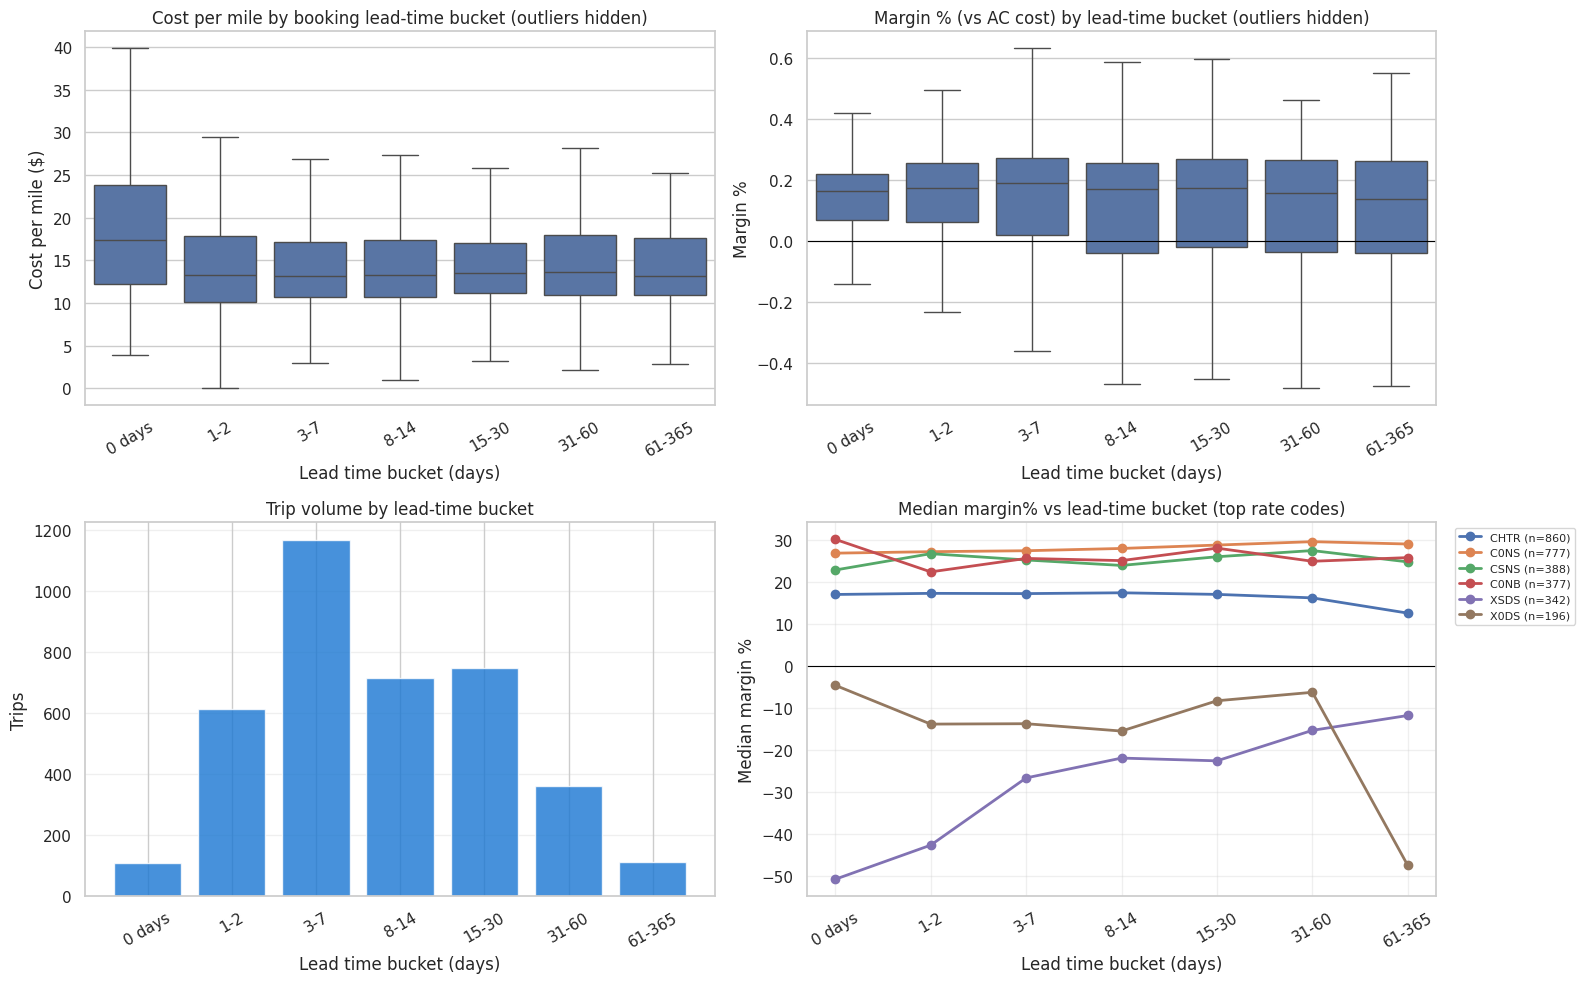

In [15]:
# Visuals
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) CPM by lead bucket
sns.boxplot(data=df_plot, x='lead_bucket', y='cost_per_mile_actual', showfliers=False, ax=axes[0,0], order=labels)
axes[0,0].set_title('Cost per mile by booking lead-time bucket (outliers hidden)')
axes[0,0].set_xlabel('Lead time bucket (days)')
axes[0,0].set_ylabel('Cost per mile ($)')
axes[0,0].tick_params(axis='x', rotation=30)

# 2) Margin% by lead bucket
sns.boxplot(data=df_plot, x='lead_bucket', y='margin_pct_vs_ac_cost', showfliers=False, ax=axes[0,1], order=labels)
axes[0,1].axhline(0, color='black', linewidth=0.8)
axes[0,1].set_title('Margin % (vs AC cost) by lead-time bucket (outliers hidden)')
axes[0,1].set_xlabel('Lead time bucket (days)')
axes[0,1].set_ylabel('Margin %')
axes[0,1].tick_params(axis='x', rotation=30)

# 3) Mix of trips by lead bucket
mix = df_plot['lead_bucket'].value_counts().reindex(labels)
axes[1,0].bar(mix.index.astype(str), mix.values, color='#1976D2', alpha=0.8)
axes[1,0].set_title('Trip volume by lead-time bucket')
axes[1,0].set_xlabel('Lead time bucket (days)')
axes[1,0].set_ylabel('Trips')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].grid(True, axis='y', alpha=0.3)

# 4) Interaction: lead bucket vs top rate codes (median margin)
# Keep top rate codes by volume for readability
rate_counts = df_plot['qRate_Type_Code'].astype('string').fillna('NA').value_counts()
rate_keep = rate_counts.head(6).index.tolist()
df_int = df_plot[df_plot['qRate_Type_Code'].astype('string').fillna('NA').isin(rate_keep)].copy()
df_int['qRate_Type_Code'] = df_int['qRate_Type_Code'].astype('string').fillna('NA')

pivot = (
    df_int.groupby(['qRate_Type_Code','lead_bucket'])
    .agg(med_margin=('margin_pct_vs_ac_cost','median'), n=('Trip_Number','size'))
    .reset_index()
)
# Plot lines of median margin by lead bucket
for rc in rate_keep:
    sub = pivot[pivot['qRate_Type_Code']==rc].set_index('lead_bucket').reindex(labels)
    axes[1,1].plot(labels, sub['med_margin']*100, marker='o', linewidth=2, label=f"{rc} (n={int(sub['n'].sum())})")

axes[1,1].axhline(0, color='black', linewidth=0.8)
axes[1,1].set_title('Median margin% vs lead-time bucket (top rate codes)')
axes[1,1].set_xlabel('Lead time bucket (days)')
axes[1,1].set_ylabel('Median margin %')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
print("test")

test
